# Section 8: Python - Machine Learning  

# Table of contents
[1. INTRODUCTION](#1.INTRODUCTION) </br>
[1.1 BUSINESS UNDERSTANDING](#1.1BUSINESS-UNDERSTANDING) </br>
[1.2 Problem Statement](#1.2Problem-Statement) </br>
[1.3 Objectives](#1.3Objectives) </br>
[1.3.1 Main Objective](#1.3.1Main-Objective) </br>
[1.3.2 Specific Objective](#1.3.2Specific-Objectives) </br>
[2. Libraries](#2.LOADING-LIBRARIES) </br>
[3. Data Understanding](#3.Data-Understanding) </br>
[4. Data Cleaning](#4.Data-Cleaning) </br>
[4.1 Dropping irrelevant-columns](#4.1Dropping-irrelevant-columns) </br>
[4.2 Checking for-duplicates](#4.2Checking-for-duplicates) </br>
[4.4 Checking for missing values](#4.4Checking-for-missing-values) </br>
[5. EXPLORATION DATA ANALYSIS](#5.EXPLORATION-DATA-ANALYSIS) </br>
[5.1 Univariate Analysis](#5.1Univariate-Analysis) </br>
[5.2 Bivariate analysis](#5.2Bivariate-analysis) </br>
[6. Feature Engineering](#6.Feature-Engineering) </br>
[7. Data Modelling](#7.Data-Modelling) </br>
[7.1 Logistic Regression](#7.1Logistic-Regression) </br>
[8. Evaluation](#8.Evaluation) </br>
[9. Conclusion](#9.Conclusion) </br>
[10. Recommendations](#10.Recommendations) </br>

# 1. Business Understanding

    • Dataset Specifications: Product performance data with columns: Product (e.g., Product A, Product B, Product C), Quantity (integer), Revenue (float), AboveAvgRevenue (binary, 1 if revenue > average, 0 otherwise); ~600 rows; supports logistic regression and visualization.  
    • Tasks:  
        1. Build a logistic regression model to predict whether a product will achieve above-average revenue (binary outcome). Use pandas for data prep and matplotlib/seaborn for visualization (e.g., ROC curve). 
    • Output: Python script file (.py) and visualization.  
    • Interpretation: In 100-150 words, interpret the model’s performance and its utility for product performance analysis.

## 1.1 Problem Statement

The task is to build a predictive model that can classify whether a product will achieve above-average revenue based on its performance data. This will help businesses better understand and forecast product performance, enabling data-driven decisions related to sales strategies, marketing efforts, and inventory management.

## 1.2 Main Objective

To develop a logistic regression model that predicts whether a product will achieve above-average revenue, using product performance data such as product type, quantity, and revenue.

## 1.3 Specific Objectives

Data Preprocessing: Clean and preprocess the dataset using pandas to prepare the data for the logistic regression model, ensuring that it is properly formatted and any missing values or inconsistencies are handled.

Model Development: Build a logistic regression model that predicts the binary outcome (AboveAvgRevenue), based on product performance data.

Visualization and Evaluation: Generate visualizations using matplotlib and seaborn to assess the model's performance, including an ROC curve to evaluate its classification ability.

# 2. Libraries And Warnings

In [45]:
import joblib
import warnings
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix, roc_curve, roc_auc_score, auc, f1_score

# 3. Data Understanding

In [46]:
data = pd.read_csv("Sample - Superstore.csv", encoding='latin1')
data

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


In [47]:
data.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [48]:
data.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [49]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [50]:
data.shape

(9994, 21)

# 4. Data Cleaning

## 4.1 Dropping Irrelevant Columns

In [51]:
# Select and rename the relevant columns
df = data[["Product Name", "Quantity", "Sales"]].copy()
df.rename(columns={
    "Product Name": "Product",
    "Sales": "Revenue"
}, inplace=True)

# Compute average revenue and add AboveAvgRevenue column
avg_revenue = df["Revenue"].mean()
df["AboveAvgRevenue"] = df["Revenue"].apply(lambda x: 1 if x > avg_revenue else 0)

# Preview the final dataset
df

,Product,Quantity,Revenue,AboveAvgRevenue
0,Bush Somerset Collection Bookcase,2,261.9600,1
1,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",3,731.9400,1
2,Self-Adhesive Address Labels for Typewriters b...,2,14.6200,0
3,Bretford CR4500 Series Slim Rectangular Table,5,957.5775,1
4,Eldon Fold 'N Roll Cart System,2,22.3680,0
...,...,...,...,...
9989,Ultra Door Pull Handle,3,25.2480,0
9990,Tenex B1-RE Series Chair Mats for Low Pile Car...,2,91.9600,0
9991,Aastra 57i VoIP phone,2,258.5760,1
9992,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",4,29.6000,0


## 4.2 Missing Values

In [52]:
df.isna().sum()

Product            0
Quantity           0
Revenue            0
AboveAvgRevenue    0
dtype: int64

## 4.3 Duplicates

In [53]:
df["Product"].duplicated().sum()

8144

Out of all rows, 8,144 have a duplicate product name (e.g., "Product A" appearing multiple times).

In [54]:
df["Quantity"].duplicated().sum()

9980

9,980 rows share the same quantity value with at least one other row.

In [55]:
df["Revenue"].duplicated().sum()

4169

4,169 rows have identical revenue values.

In [56]:
df["AboveAvgRevenue"].duplicated().sum()

9992

9,992 rows have a duplicate value of either 1 or 0 (binary, so expected to have many repeats).

In [57]:
df.duplicated().sum()

1603

1,603 rows in the entire DataFrame are completely duplicated across all four columns. This are repetition of transactions so we drop them

In [58]:
# dropping the duplicates
df.drop_duplicates(inplace=True)

In [59]:
# checking if the duplicates have been dropped
df.duplicated().sum()

0

# 5. EDA

## 5.1 Univariate Analysis

### Frequency distribution of Product

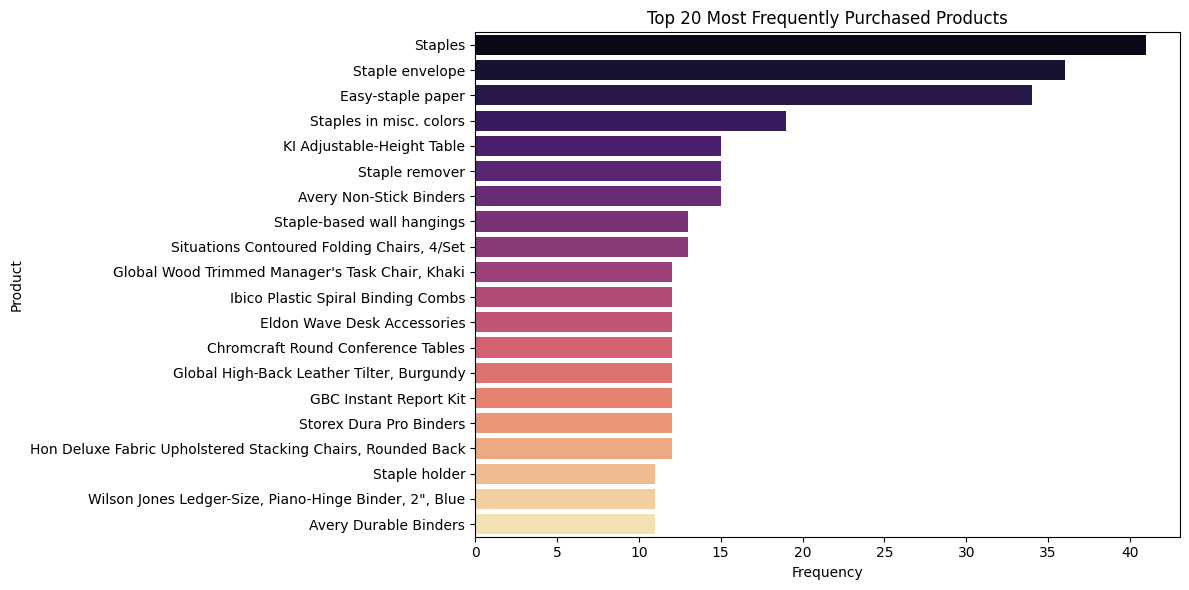

In [60]:
# Count how often each product appears
product_counts = df['Product'].value_counts().head(20)  # Show top 20 most frequent products

plt.figure(figsize=(12, 6))
sns.barplot(x=product_counts.values, y=product_counts.index, palette="magma")
plt.title('Top 20 Most Frequently Purchased Products')
plt.xlabel('Frequency')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

### Histogram plot of Quantity

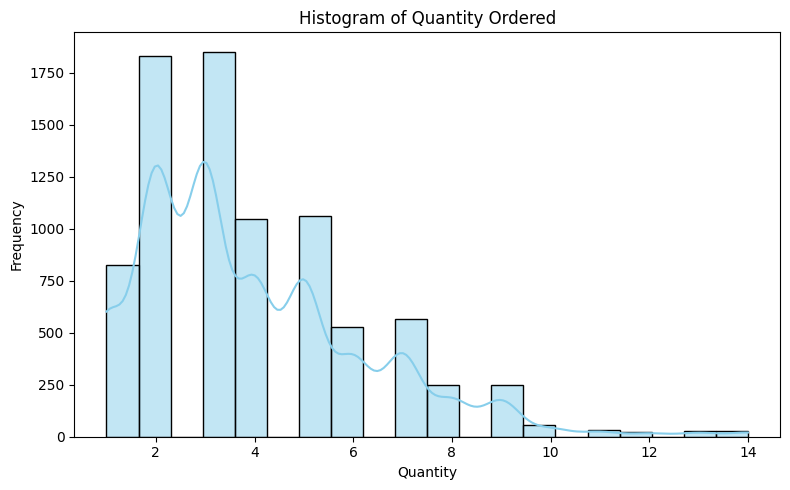

In [61]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Quantity'], bins=20, kde=True, color="skyblue")
plt.title('Histogram of Quantity Ordered')
plt.xlabel('Quantity')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Histogram of Revenue

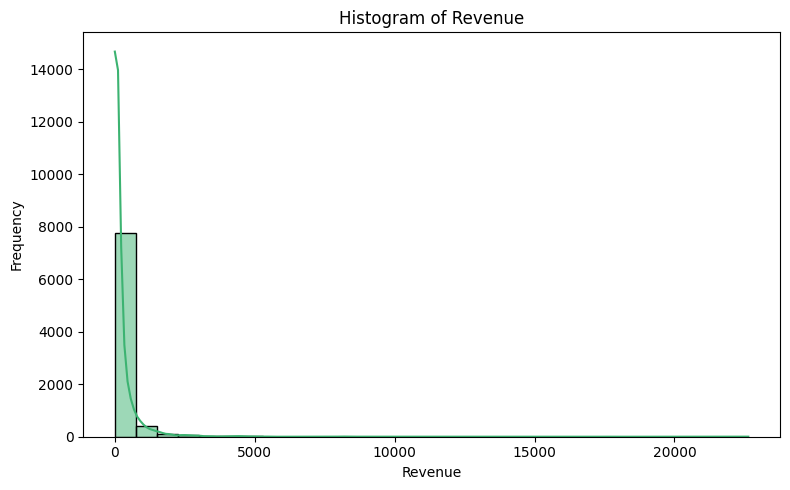

In [62]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Revenue'], bins=30, kde=True, color="mediumseagreen")
plt.title('Histogram of Revenue')
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [63]:
df.columns

Index(['Product', 'Quantity', 'Revenue', 'AboveAvgRevenue'], dtype='object')

### Countplot of AboveAvgRevenue

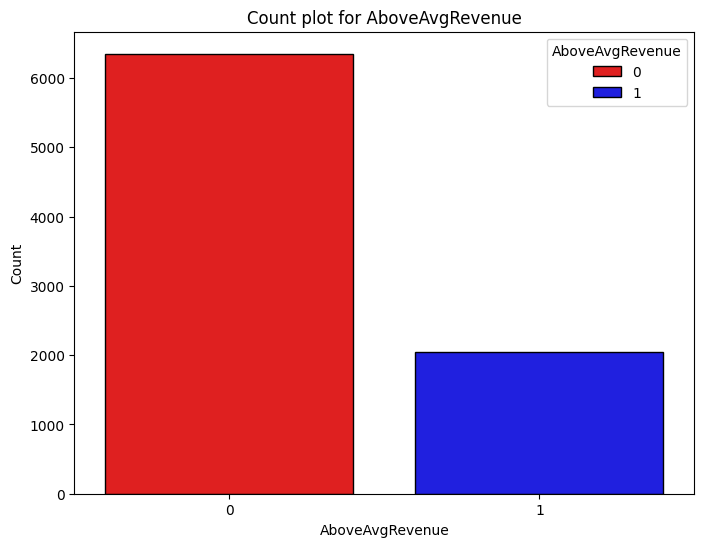

In [64]:
# plotting the figure size
plt.figure(figsize=(8, 6))

# countplot 
sns.countplot(data = df, x = "AboveAvgRevenue", hue = "AboveAvgRevenue", palette={"Blue", "Red"}, edgecolor='black')

# labels
plt.title("Count plot for AboveAvgRevenue")
plt.xlabel("AboveAvgRevenue")
plt.ylabel("Count")
plt.legend(title = "AboveAvgRevenue", labels = ["0", "1"])

# Display the visual;
plt.show()

## 5.2 Bivariate Analysis

### Scatter plot of Quantity vs Revenue

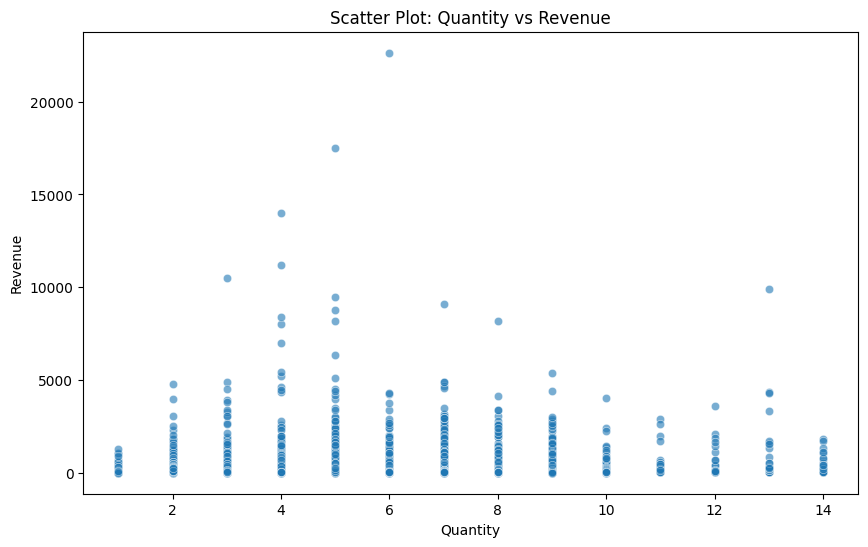

In [65]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Quantity', y='Revenue', alpha=0.6)
plt.title('Scatter Plot: Quantity vs Revenue')
plt.xlabel('Quantity')
plt.ylabel('Revenue')
plt.show()

### Barplot of average Revenue per Product

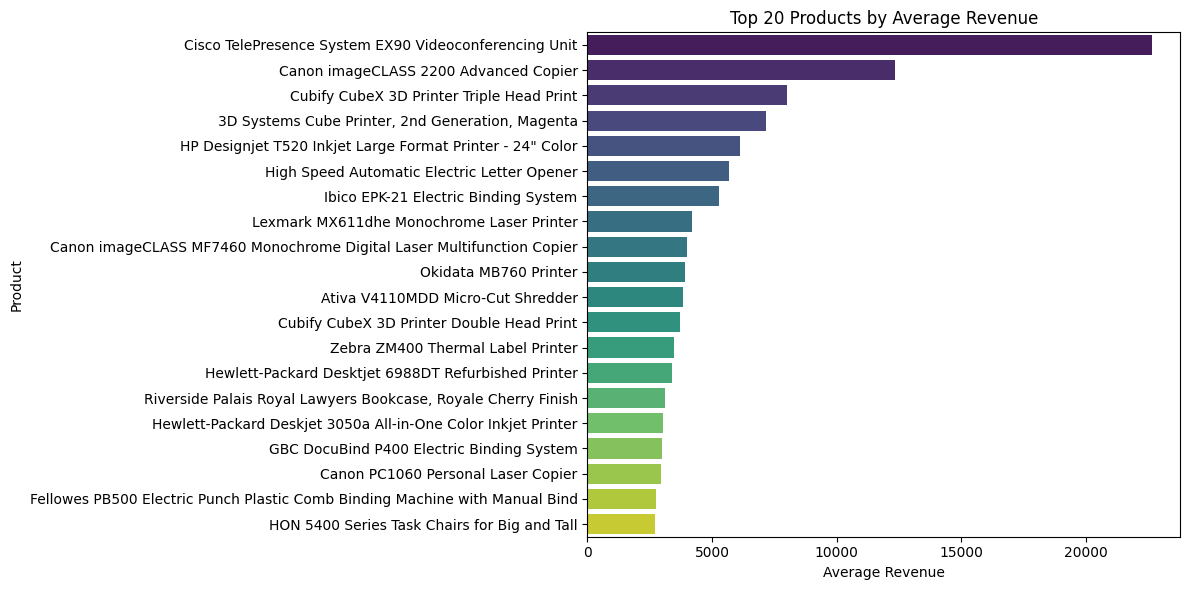

In [66]:
# Calculate average revenue per product
avg_revenue = df.groupby("Product")["Revenue"].mean().sort_values(ascending=False).head(20)  # top 20 for clarity

plt.figure(figsize=(12, 6))
sns.barplot(x=avg_revenue.values, y=avg_revenue.index, palette='viridis')
plt.title('Top 20 Products by Average Revenue')
plt.xlabel('Average Revenue')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

## 5.3 Multivariate Analysis

### Heatmap of correlation matrix (Quantity, Revenue, AboveAvgRevenue)

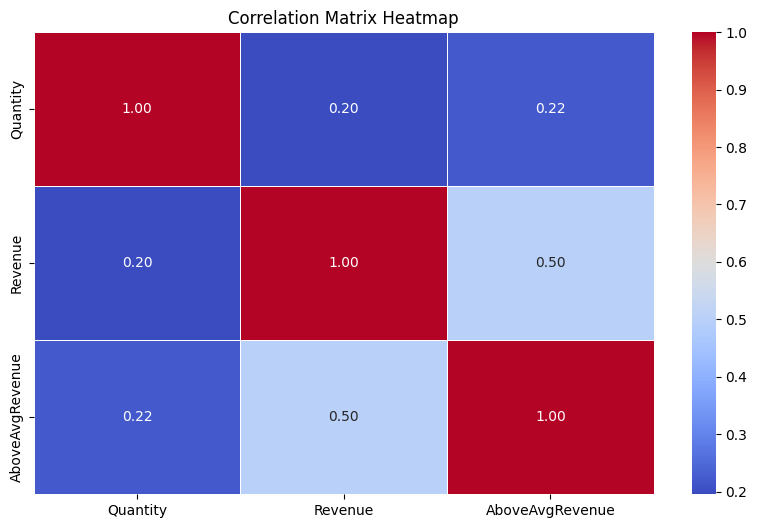

In [67]:
# Select relevant columns
corr_data = df[['Quantity', 'Revenue', 'AboveAvgRevenue']]

# Compute the correlation matrix
corr_matrix = corr_data.corr()

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()

### Interpretation

Quantity and Revenue:

    Correlation: 0.20 (positive, but relatively weak)
    Interpretation: There is a slight tendency for higher quantities to be associated with higher revenue, but the relationship is not very strong.

Quantity and AboveAvgRevenue:

    Correlation: 0.22 (positive, but relatively weak)
    Interpretation: Similar to revenue, higher quantities show a slight tendency to be associated with values Above the Average Revenue, but the relationship is not very strong.

Revenue and AboveAvgRevenue:

    Correlation: 0.50 (moderate positive)
    Interpretation: There is a moderate positive correlation between revenue and AboveAvgRevenue. This indicates that higher revenues are more likely to be associated with values that are above the average revenue. This relationship is stronger than the relationships involving quantity.

# 6. Feature Engineering

## 6.1 One Hot Encoding

In [68]:
# Handle categorical data - One Hot Encoding for Product
df = pd.get_dummies(df, columns=["Product"], drop_first=True)
df

,Quantity,Revenue,AboveAvgRevenue,"Product_#10 Gummed Flap White Envelopes, 100/Box",Product_#10 Self-Seal White Envelopes,"Product_#10 White Business Envelopes,4 1/8 x 9 1/2","Product_#10- 4 1/8"" x 9 1/2"" Recycled Envelopes","Product_#10- 4 1/8"" x 9 1/2"" Security-Tint Envelopes","Product_#10-4 1/8"" x 9 1/2"" Premium Diagonal Seam Envelopes",Product_#6 3/4 Gummed Flap White Envelopes,...,Product_Zebra ZM400 Thermal Label Printer,Product_Zebra Zazzle Fluorescent Highlighters,Product_Zipper Ring Binder Pockets,Product_i.Sound Portable Power - 8000 mAh,Product_iHome FM Clock Radio with Lightning Dock,"Product_iKross Bluetooth Portable Keyboard + Cell Phone Stand Holder + Brush for Apple iPhone 5S 5C 5, 4S 4",Product_iOttie HLCRIO102 Car Mount,Product_iOttie XL Car Mount,Product_invisibleSHIELD by ZAGG Smudge-Free Screen Protector,Product_netTALK DUO VoIP Telephone Service
0,2,261.9600,1,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,3,731.9400,1,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2,14.6200,0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,5,957.5775,1,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2,22.3680,0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9985,4,55.6000,0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9987,1,79.9900,0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9989,3,25.2480,0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9992,4,29.6000,0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## 6.2 Feature scaling

In [69]:
scaler = StandardScaler()
df[['Quantity', 'Revenue']] = scaler.fit_transform(df[['Quantity', 'Revenue']])

## 6.3 Train Test Split

In [70]:
X = df.drop(columns=["AboveAvgRevenue"])
y = df["AboveAvgRevenue"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 7. Data Modelling

## 7.1 Logistic Regression

Accuracy: 0.9881
ROC-AUC: 0.9762


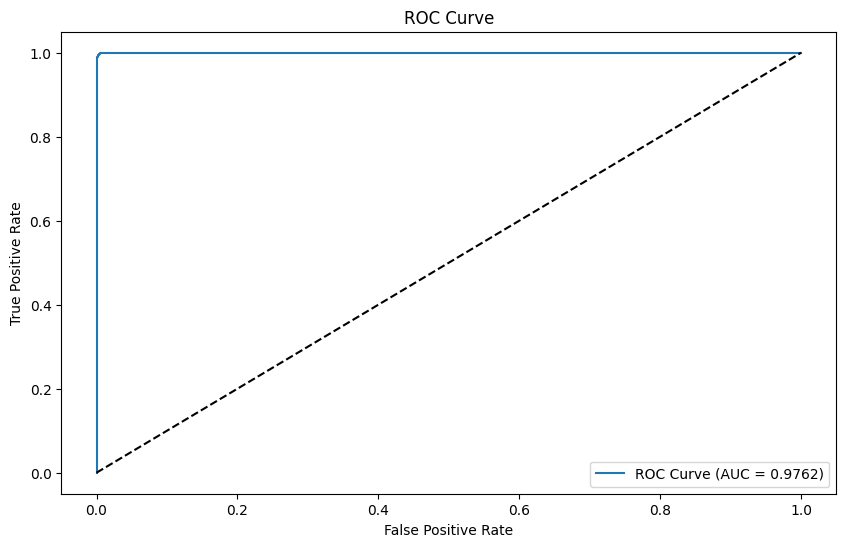

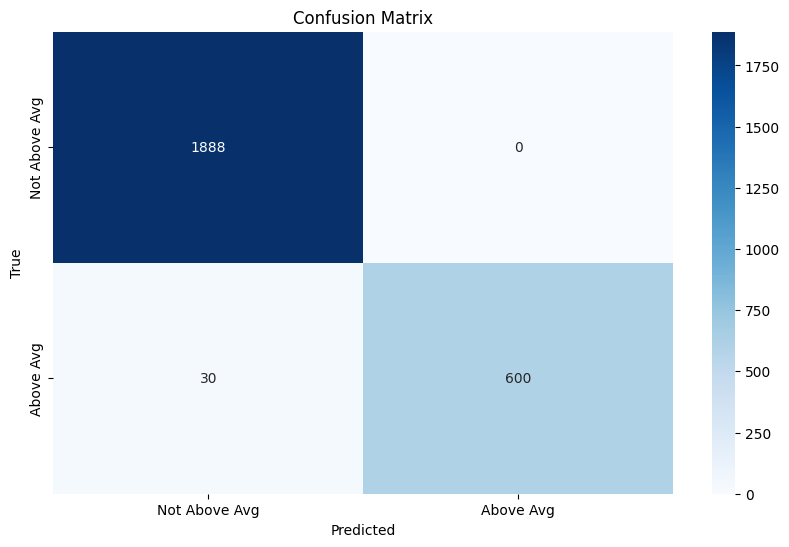

In [74]:
# Fitting the model
model = LogisticRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred)
print(f"ROC-AUC: {roc_auc:.4f}")

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Not Above Avg", "Above Avg"], yticklabels=["Not Above Avg", "Above Avg"])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# 8. Conclusions

# 9. Recommendations